# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'AppleGothic'   # Windows는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print("Read csv")
df = pd.read_csv('marketing_customers.csv')

print("print five head lines")
df.head()

print("print five tail lines")
df.tail()

Read csv
print five head lines
print five tail lines


,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
5995,5996,51,Female,Social Ads,Silver,7,0.156,2.52,3.32,5.84,treatment,1,19.23
5996,5997,33,Female,Influencer,Basic,1,0.364,11.37,7.86,19.23,treatment,0,37.87
5997,5998,68,Male,Organic Search,Basic,4,0.092,7.50,0.72,8.22,control,0,15.39
5998,5999,49,Female,Influencer,Silver,5,0.093,4.30,9.20,13.50,treatment,1,33.62
5999,6000,33,Male,Social Ads,Basic,4,0.033,26.06,5.29,31.35,control,0,13.30


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [2]:
print(f'row : {df.shape[0]}')
print(f'column : {df.shape[1]}')
print("========================================================")
print(df.dtypes)
print("========================================================")
print(df.describe())
print("========================================================")
result_df = df.isnull().sum().reset_index()
result_df.columns = ['변수명', '결측치 개수']
print(result_df)

row : 6000
column : 13
customer_id            int64
age                    int64
gender                   str
signup_channel           str
membership_tier          str
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group           str
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.0

> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.
> 고객 규모는 총 6000명이였고 연령대는 18 ~ 78세, 월 방문 횟수는 1 ~ 34번, 총 광고비는 $0.59 ~ $68.2, 월 구매액은 $8.26 ~ $288.44의 범주를 가지고 있었습니다

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

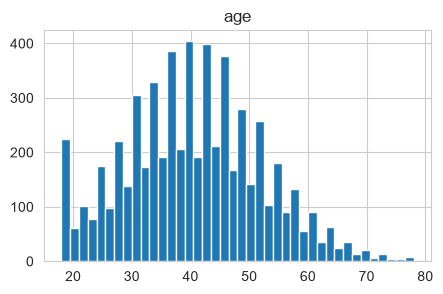

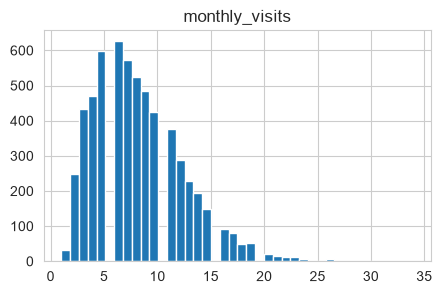

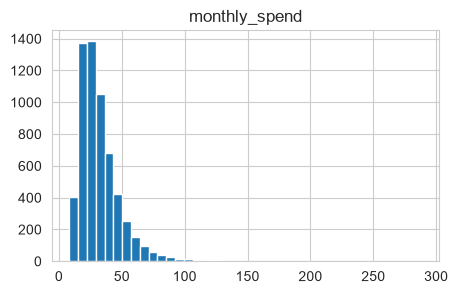

왜도 = 2.5456526289788064

monthly spend 의 히스토그램


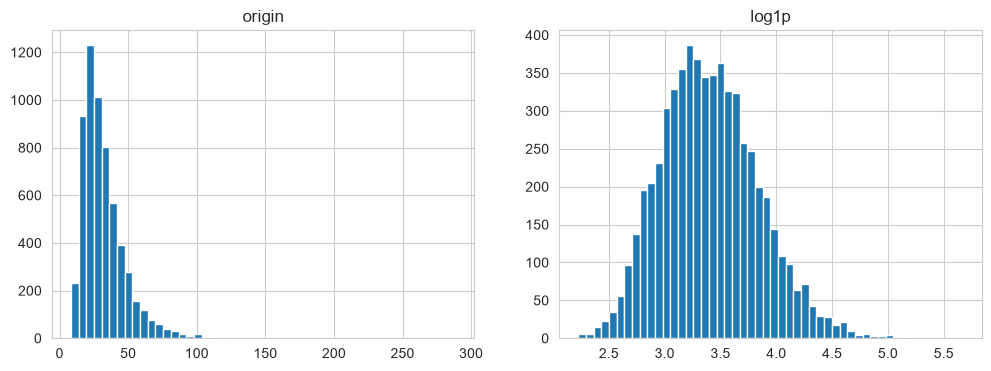

사용료 150이상의 부자들 :       monthly_spend  customer_id
256          288.44          257
1178         153.03         1179
1518         151.19         1519
2234         169.21         2235
2840         151.87         2841
4776         153.99         4777
5951         183.28         5952


In [3]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()
print('왜도 =', skew)
print("")

print("monthly spend 의 히스토그램")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['monthly_spend'], bins=50) # 히스토그램 작성
axes[0].set_title('origin') # 히스토그램 제목 작성

axes[1].hist(np.log1p(df['monthly_spend']), bins=50)  
axes[1].set_title('log1p'); plt.show()

rich = df[(df['monthly_spend'] > 150)]
rich = rich[['monthly_spend','customer_id']]

print(f'사용료 150이상의 부자들 : {rich}')

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요.
- 월 구매액이 150이상인 소수의 사람들까지 히스토그램에 반영하다보니 너무 넓은 범위를 잡고 히스토그램을 그리게 되었고 이 소수의 사람들 때문에 매출 분포가 치우쳐져서 보인다

**3. 채널·등급별 매출 Boxplot**

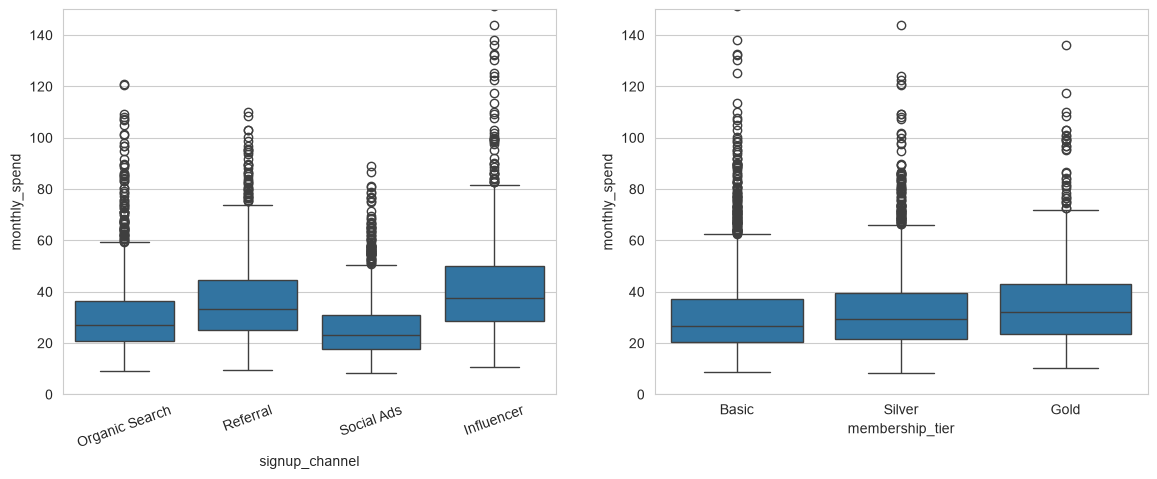

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요.
- influencer 채널로 들어온 고객과 Gold tier의 고객이 고가치 고객으로 보인다

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.
- 1종 오류 : 쿠폰 캠페인은 실제로 효과가 없지만 효과가 있다고 착각하는 것을 의미합니다. 이 오류에 빠질 경우 기업은 쿠폰을 남발하다가 매출 상승액보다 쿠폰 발급비용이 더 커지는 손해를 보게 됩니다.
- 2종 오류 : 쿠폰 캠페인은 실제로 효과가 있지만 효과가 없다고 착각하는 것을 의미합니다. 이 오류에 빠질 경우 매출 상승 효과가 있는 쿠폰을 발급하지 않아서 잠재적 매출 상승 효과를 얻지 못하는 기회비용 측면의 손해를 보게 됩니다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

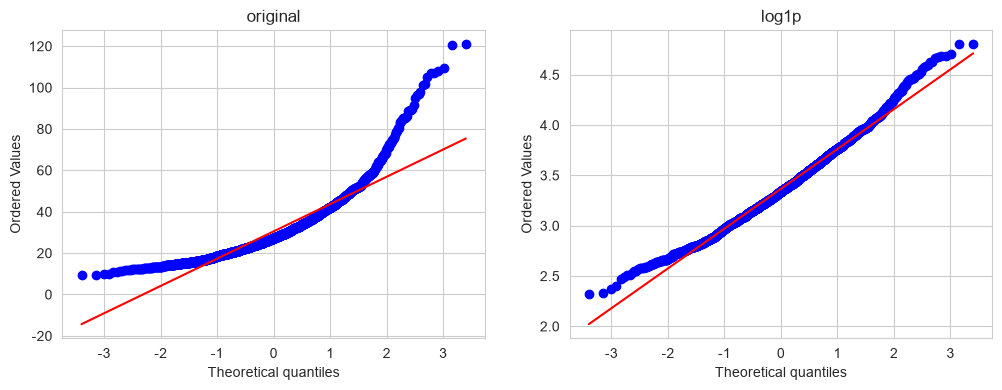

원본 p-value :  3.631642400264097e-21
log1p p-value :  0.00024486116128258806


In [5]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('original')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본 p-value : ', stats.shapiro(xs)[1])          # 힌트: shapiro
print('log1p p-value : ', stats.shapiro(np.log1p(xs))[1])

> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요.
- 귀무가설 : 데이터가 정규분포를 따를 것이다
- 원본데이터는 p-value가 3.62e-21으로 매우 작다. 그러므로 이 데이터는 귀무가설을 아주 강력하게 기각한다, 즉 완벽한 정규분포가 아닌 것이다
- log(x+1)값을 취한 정규화시킨 데이터의 p-value는 0.00024이고 이 역시 0.05보다 작다. 그러므로 이 데이터 역시 귀무가설을 기각한다. 그러나 원본 데이터에 비해 p-value가 극적으로 높아졌으므로 로그 스케일링은 정규화에 많은 도움을 준다는 것을 알 수 있다

**6. 등분산성 검정**

In [6]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups) 
print(df.groupby('signup_channel')['monthly_spend'].var())
print('Levene p =', p)

signup_channel
Influencer        550.876953
Organic Search    203.411751
Referral          266.317866
Social Ads        136.926275
Name: monthly_spend, dtype: float64
Levene p = 4.335927248189438e-44


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요.
- 귀무가설: "모든 채널의 분산은 똑같을 것이다 (등분산이다).
- 논리적 전제: 만약 분산들의 차이가 등분산에 준할 만큼 아주 사소했다면, 표본 오차로 인해 우연히 그런 차이가 발생할 확률(p-value)은 0.05보다 크게 나왔을 것이다.
- 현실과 결론: 하지만 실제 계산된 p-value는 4.34e-44 로 말도 안 되게 작게 나왔다.
- 결론: 따라서 눈앞에 관찰된 분산의 격차는 단순한 우연이나 사소한 오차가 아니라, 채널 간 분산이 실제로 꽤 크게 차이 나는 '등분산이 아닌 상황'이다!
- Levene의 등분산성 검정 결과 p-value가 4.34e-44 로 유의수준 $0.05$보다 매우 작으므로 등분산성 가정이 위배되었습니다.이는 ANOVA의 기본 전제를 충족하지 못함을 의미하며, 이 상태로 ANOVA를 수행할 경우 분석 결과의 신뢰성이 떨어집니다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [7]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']  
print('쿠폰 받은 그룹의 월 구매액 평균 : ', trt.mean())
print('쿠폰 안받은 그룹의 월 구매액 평균 : ', ctrl.mean())

p_value = stats.levene(ctrl, trt).pvalue
print('Levene p =', p_value)
# 등분산이 깨지면 equal_var=False (Welch)
if (p_value < 0.05): #등분산이 깨지면
    t, p = stats.ttest_ind(ctrl, trt, equal_var=False)
    print('t=%.2f p=%.3g' % (t, p))

쿠폰 받은 그룹의 월 구매액 평균 :  34.80327820046312
쿠폰 안받은 그룹의 월 구매액 평균 :  29.707517635203224
Levene p = 1.1644920921295873e-19
t=-11.88 p=3.86e-32


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요.
- H0(귀무가설)은 "쿠폰을 받은 사용자들의 월 구매액이 높은 것은 쿠폰 발송이랑 관련없다" 이다
- H1(대립가설)은 "쿠폰을 받은 사용자들의 월 구매액이 높은 것은 쿠폰 발송이랑 관계가 있다" 이다
- 데이터를 통해 쿠폰을 안받은 그룹보다 받은 그룹의 월 구매액이 크다는 것을 알 수 있고 p-value값이 3.86e-32로 0.05보다 매우 작으므로 데이터는 믿을만하다. 따라서 캠페인을 지속해야 한다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [8]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

if(p < 0.05):
    tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)  
    print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요.
- 귀무가설 : 고객 유입채널에 따른 월 지출액 평균에는 차이가 없다
- 대립가설 : 적어도 하나의 유입채널간 월 지출액 평균에는 차이가 있다
- ANOVA 검정 결과 F=276.85로 각 채널 안에서 널뛰는 개인차(소음)보다 채널 간 평균 차이(신호)가 277배 정도 크게 관측되었다. 또한 p-value가 2.67e-168로 0.05보다 훨씬 작으므로 귀무가설을 기각한다.
- 이어 진행한 사후검정 결과 모든 채널 조합에서 reject = True (p < 0.05)가 나와 4개 채널 간 평균 지출액 차이가 전부 통계적으로 유의함이 입증되었다.
- 따라서 사후검정으로 통계적 유의성이 확인되었고 지출액 평균이 가장 높은 Social Ads가 유의하게 고가치 채널이며, 가장 낮은 Influencer가 유의하게 저가치 채널이다.

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [9]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요.
- 귀무가설(채널 주효과): 유입채널에 따른 월 구매액 평균에는 차이가 없다
- 귀무가설(캠페인 주효과): 캠페인(쿠폰) 발송 여부에 따른 월 구매액 평균에는 차이가 없다
- 귀무가설(교호작용): 채널과 캠페인 간 교호작용은 없다 (쿠폰 효과는 모든 채널에서 동일하다)
- 분석 결과 signup_channel의 F=284.97, p=6.34e-173, campaign_group의 F=159.79, p=3.63e-36, 교호작용의 F=9.29, p=3.97e-06으로 세 가설 모두 p<0.05이므로 귀무가설을 모두 기각한다.
- 즉 채널별 평균 매출이 다르고(8번과 일치), 쿠폰을 받은 그룹이 평균적으로 더 높은 매출을 보이며(7번과 일치), 여기에 더해 쿠폰의 효과 크기 자체가 채널마다 유의하게 다르다는 것이 확인되었다.
- 채널별 control→treatment 평균 매출 상승폭을 보면 Influencer가 37.86→47.83(약 +9.97)로 가장 크게 뛰었고, Organic Search(+4.62), Referral(+4.37), Social Ads(+3.59)는 상대적으로 상승폭이 작았다.
- 따라서 "캠페인 효과가 채널마다 다른가?"에 대한 답은 "그렇다"이며, 특히 Influencer 채널 고객에게 쿠폰을 발송했을 때 매출 증가 효과가 가장 크므로, 다음 분기 쿠폰 예산은 Influencer 채널 고객에게 우선 배분하는 것이 효율적이다.


## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [ ]:
# 단순
m1 = smf.ols('monthly_spend ~ ____', data=df).fit()   
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

In [ ]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(_____) + C(____)', data=df).fit()     #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나?

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [ ]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', ____]] 
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요.

**12. 잔차 진단** (+ 로그변환 비교)

In [ ]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요.

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [ ]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.____(logit.params)})  
print(odds.round(3))

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요.

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)